In [56]:
# Import all required modules
# Disable warnings
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Import plotting modules and set up
import seaborn as sns

sns.set()
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Tune the visual settings for figures in `seaborn`
sns.set_context(
    "notebook", font_scale=1.5, rc={"figure.figsize": (11, 8), "axes.titlesize": 18}
)

from matplotlib import rcParams

rcParams["figure.figsize"] = 11, 8

In [3]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [4]:
df = pd.read_csv(DATA_PATH + "mlbootcamp5_train.csv", sep=";")
print("Dataset size: ", df.shape)
df.head()

Dataset size:  (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'active'),
  Text(1, 0, 'alco'),
  Text(2, 0, 'cardio'),
  Text(3, 0, 'cholesterol'),
  Text(4, 0, 'gender'),
  Text(5, 0, 'gluc'),
  Text(6, 0, 'smoke')])

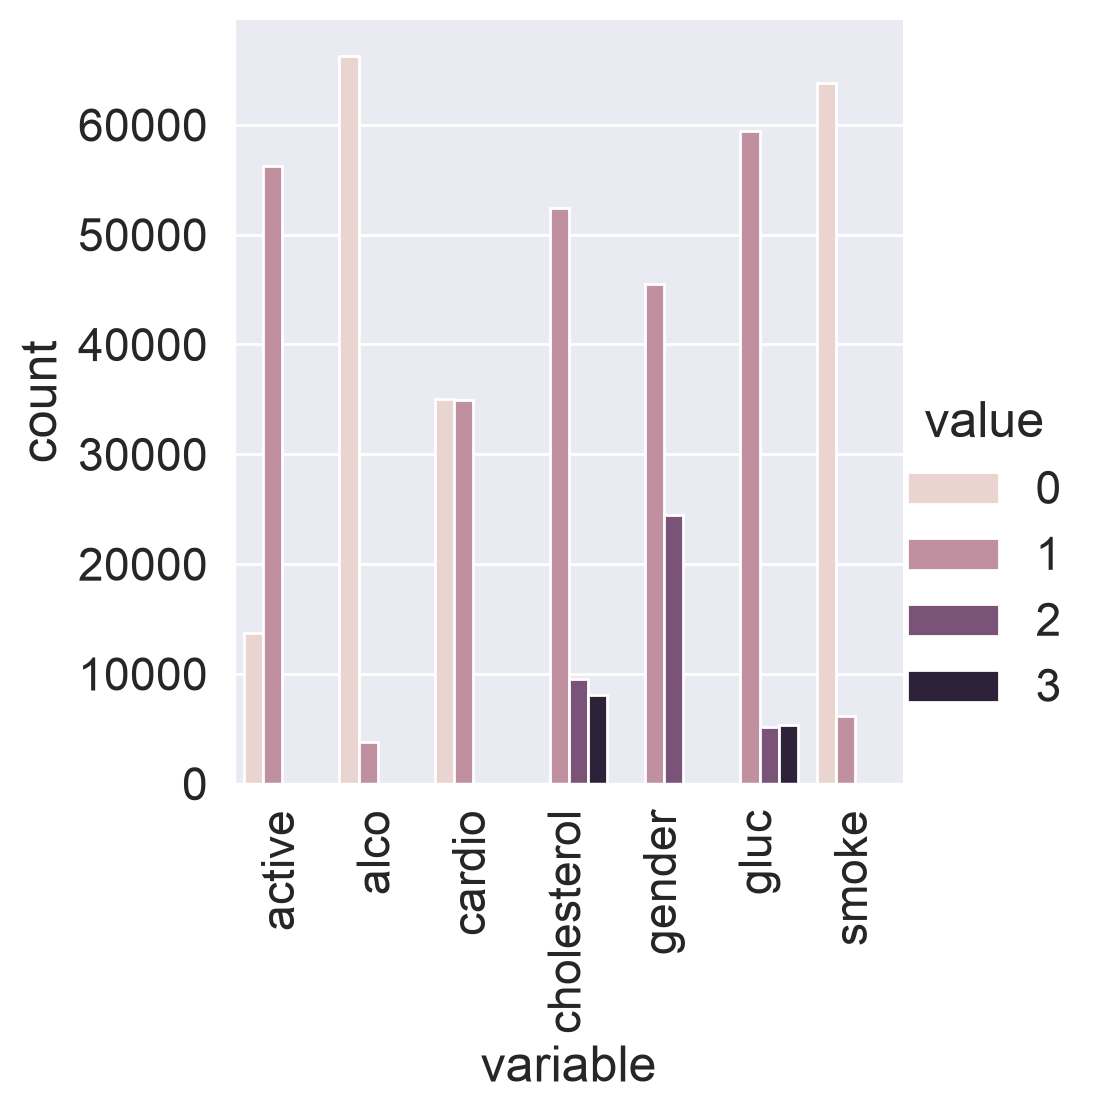

In [ ]:
df_uniques = pd.melt(frame = df, value_vars=['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'])
df_uniques = (pd.DataFrame(df_uniques.groupby(['variable', 'value'])['value'].count())
                            .sort_index(level=[0,1])
                            .rename(columns={"value": 'count'})
                            .reset_index()
            )

sns.catplot(x='variable', y='count', hue='value', data=df_uniques, kind='bar')
plt.xticks(rotation='vertical')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'active'),
  Text(1, 0, 'alco'),
  Text(2, 0, 'cholesterol'),
  Text(3, 0, 'gender'),
  Text(4, 0, 'gluc'),
  Text(5, 0, 'smoke')])

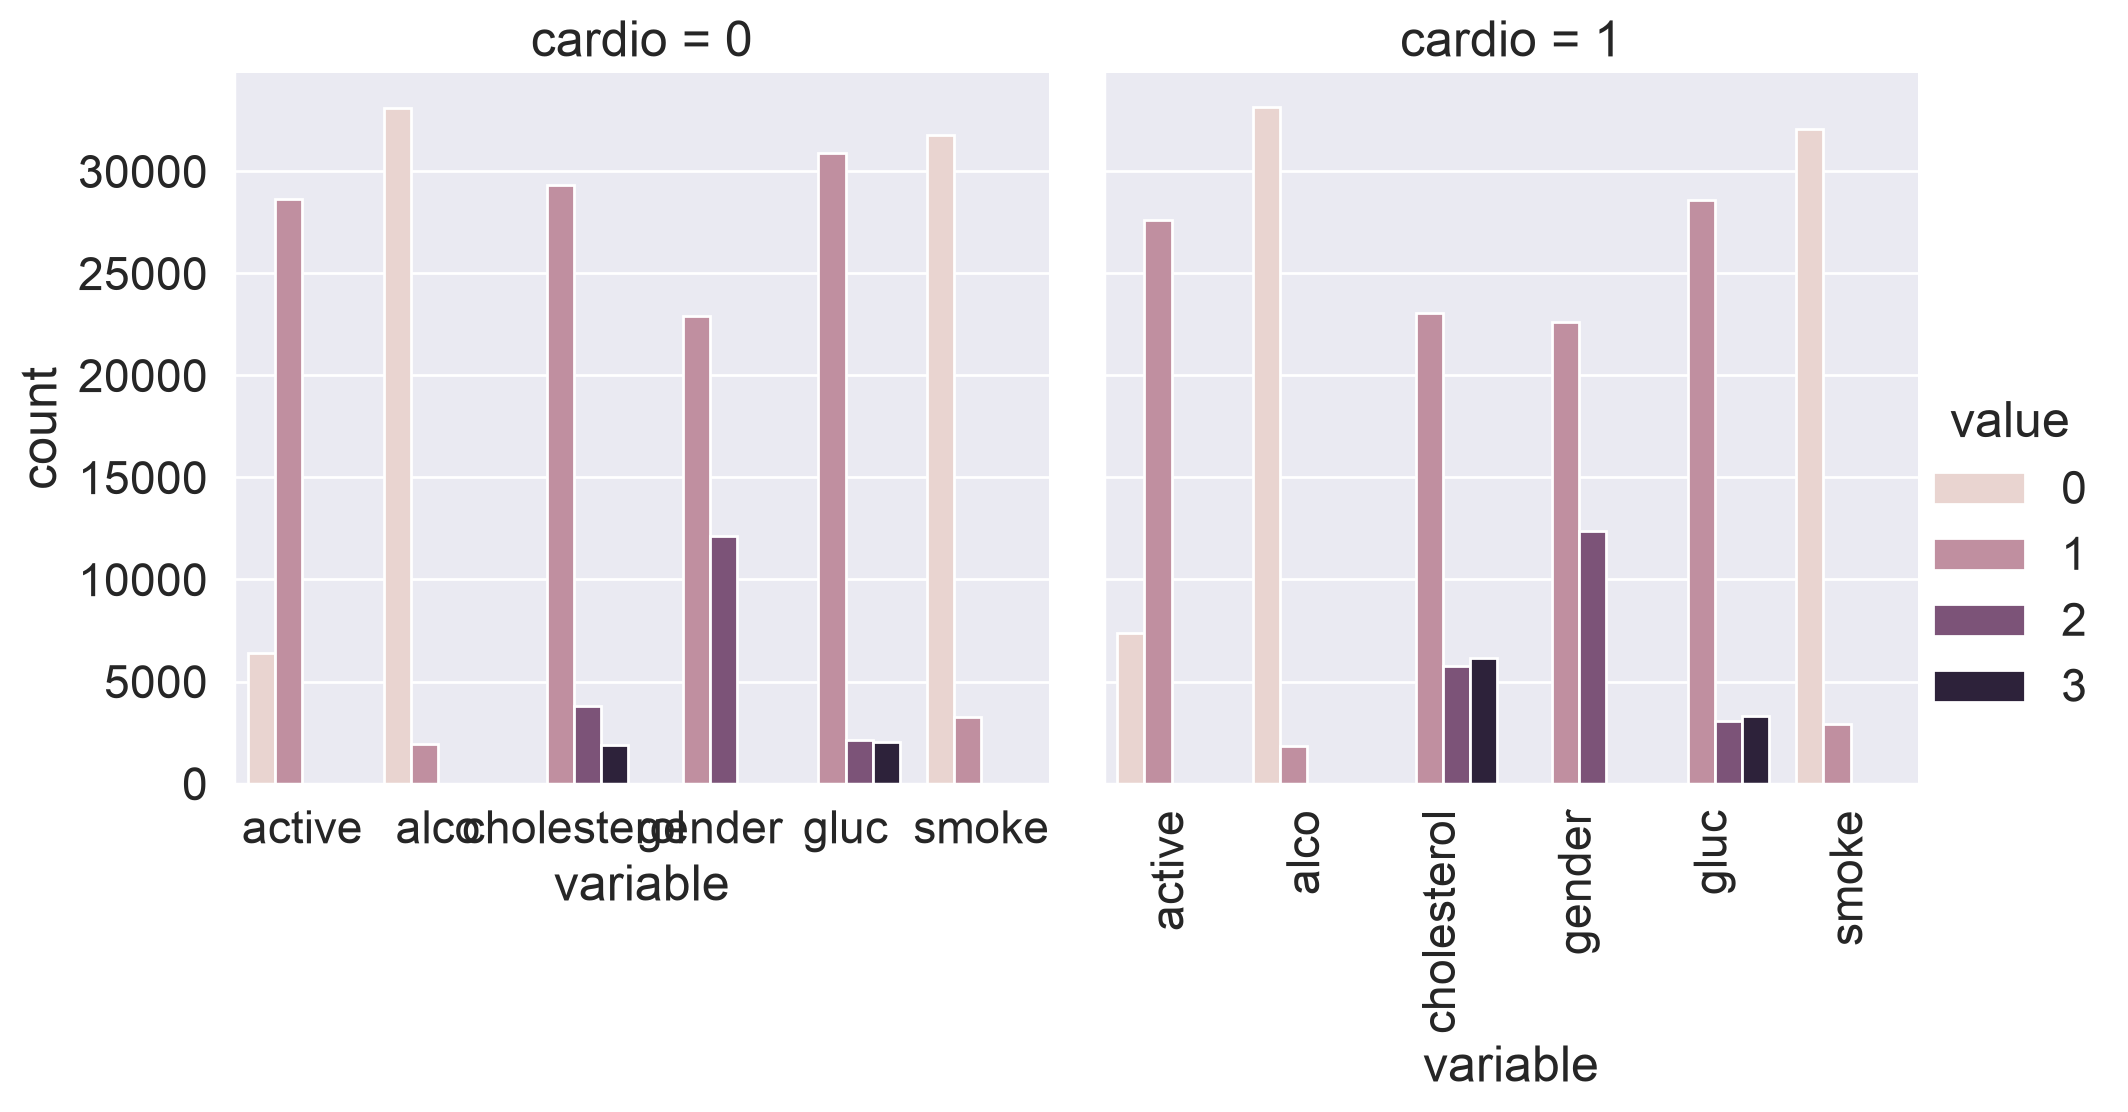

In [6]:
df_uniques = pd.melt(frame=df, value_vars=['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'], id_vars=['cardio'])
df_uniques = (pd.DataFrame(df_uniques.groupby(['variable', 'value', 'cardio'])['value'].count())
              .sort_index(level=[0,1])
              .rename(columns={'value': 'count'})
              .reset_index()
              )

sns.catplot(x='variable', y='count', hue='value', col='cardio', data=df_uniques, kind='bar')
plt.xticks(rotation='vertical')

In [7]:
for c in df.columns:
    n = df[c].nunique()
    print(c)
    
    if n<=3:
        print(n, sorted(df[c].value_counts().to_dict().items()))
    else:
        print(n)
    print(10*'-')

id
70000
----------
age
8076
----------
gender
2 [(1, 45530), (2, 24470)]
----------
height
109
----------
weight
287
----------
ap_hi
153
----------
ap_lo
157
----------
cholesterol
3 [(1, 52385), (2, 9549), (3, 8066)]
----------
gluc
3 [(1, 59479), (2, 5190), (3, 5331)]
----------
smoke
2 [(0, 63831), (1, 6169)]
----------
alco
2 [(0, 66236), (1, 3764)]
----------
active
2 [(0, 13739), (1, 56261)]
----------
cardio
2 [(0, 35021), (1, 34979)]
----------


In [9]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


#### Question 1.1
How many men and women are present in this dataset? Values of the `gender` feature were not given (wheter '1' stands for women or for men) - figure this out by analyzing height, making assumption that men are taller on average.

In [14]:
avg = df.groupby('gender')['height'].mean()
counts = df.groupby('gender')['gender'].value_counts()

print('average heights:', avg, '\ncounts by gender:', counts)

average heights: gender
1    161.355612
2    169.947895
Name: height, dtype: float64 
counts by gender: gender
1    45530
2    24470
Name: count, dtype: int64


#### Question 1.2
Who more often report consuming alcohol - men or women?

In [15]:
df.groupby('gender')['alco'].value_counts()

gender  alco
1       0       44369
        1        1161
2       0       21867
        1        2603
Name: count, dtype: int64

#### Question 1.3
What’s the rounded difference between the percentages of smokers among men and women?

In [19]:
df.groupby('gender')['smoke'].value_counts(normalize=True) * 100

gender  smoke
1       0        98.214364
        1         1.785636
2       0        78.111974
        1        21.888026
Name: proportion, dtype: float64

#### Question 1.4
What’s the rounded difference between median values of `age` (in months) for non-smokers and smokers? You’ll need to figure out the units of feature age in this dataset.

In [27]:
df.groupby('smoke')['age'].median() / 365 * 12

smoke
0    648.394521
1    628.767123
Name: age, dtype: float64

#### Question 1.5
Calculate fractions of ill people (with CVD) in the two groups of people described in the task. What’s the ratio of these two fractions?

In [34]:
df['age_years'] = (df['age'] / 365).round().astype(int)

smoking_old_men = df[(df['gender'] == 2) & (df['smoke'] == 1) & (df['age_years'].between(60,64))]

low_risk = smoking_old_men[(smoking_old_men['cholesterol'] == 1) & (smoking_old_men['ap_hi'] < 120)]['cardio'].mean()
high_risk = smoking_old_men[(smoking_old_men['cholesterol'] == 3) & (smoking_old_men['ap_hi'] < 180) & (smoking_old_men['ap_hi'] >= 160)]['cardio'].mean()

low_risk, high_risk, high_risk / low_risk

(np.float64(0.2564102564102564),
 np.float64(0.8636363636363636),
 np.float64(3.3681818181818186))

### 1.3 Analyzing BMI

In [41]:
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48,23.011177


In [48]:
median_bmi = df['BMI'].median()
avg_bmi_by_gender = df.groupby('gender')['BMI'].mean()
healthy_median = df.groupby('cardio')['BMI'].median()
healthy_non_drinking = df[(df['cardio'] == 0) & (df['alco'] == 0)].groupby('gender')['BMI'].mean()


median_bmi, avg_bmi_by_gender, healthy_median, healthy_non_drinking

(np.float64(26.374068120774975),
 gender
 1    27.987583
 2    26.754442
 Name: BMI, dtype: float64,
 cardio
 0    25.476660
 1    27.471384
 Name: BMI, dtype: float64,
 gender
 1    26.845407
 2    25.872638
 Name: BMI, dtype: float64)

### 1.4 Cleaning data

In [ ]:
df_clean = df[
    (df['ap_hi'] >= df['ap_lo']) &
    (df['height'] >= df['height'].quantile(0.025)) &
    (df['height'] <= df['height'].quantile(0.975)) &
    (df['weight'] >= df['weight'].quantile(0.025)) &
    (df['weight'] <= df['weight'].quantile(0.975))
    ]

(1 - df_clean.shape[0] / df.shape[0]) * 100


9.630000000000006

### 2.1 Correlation matrix visualization

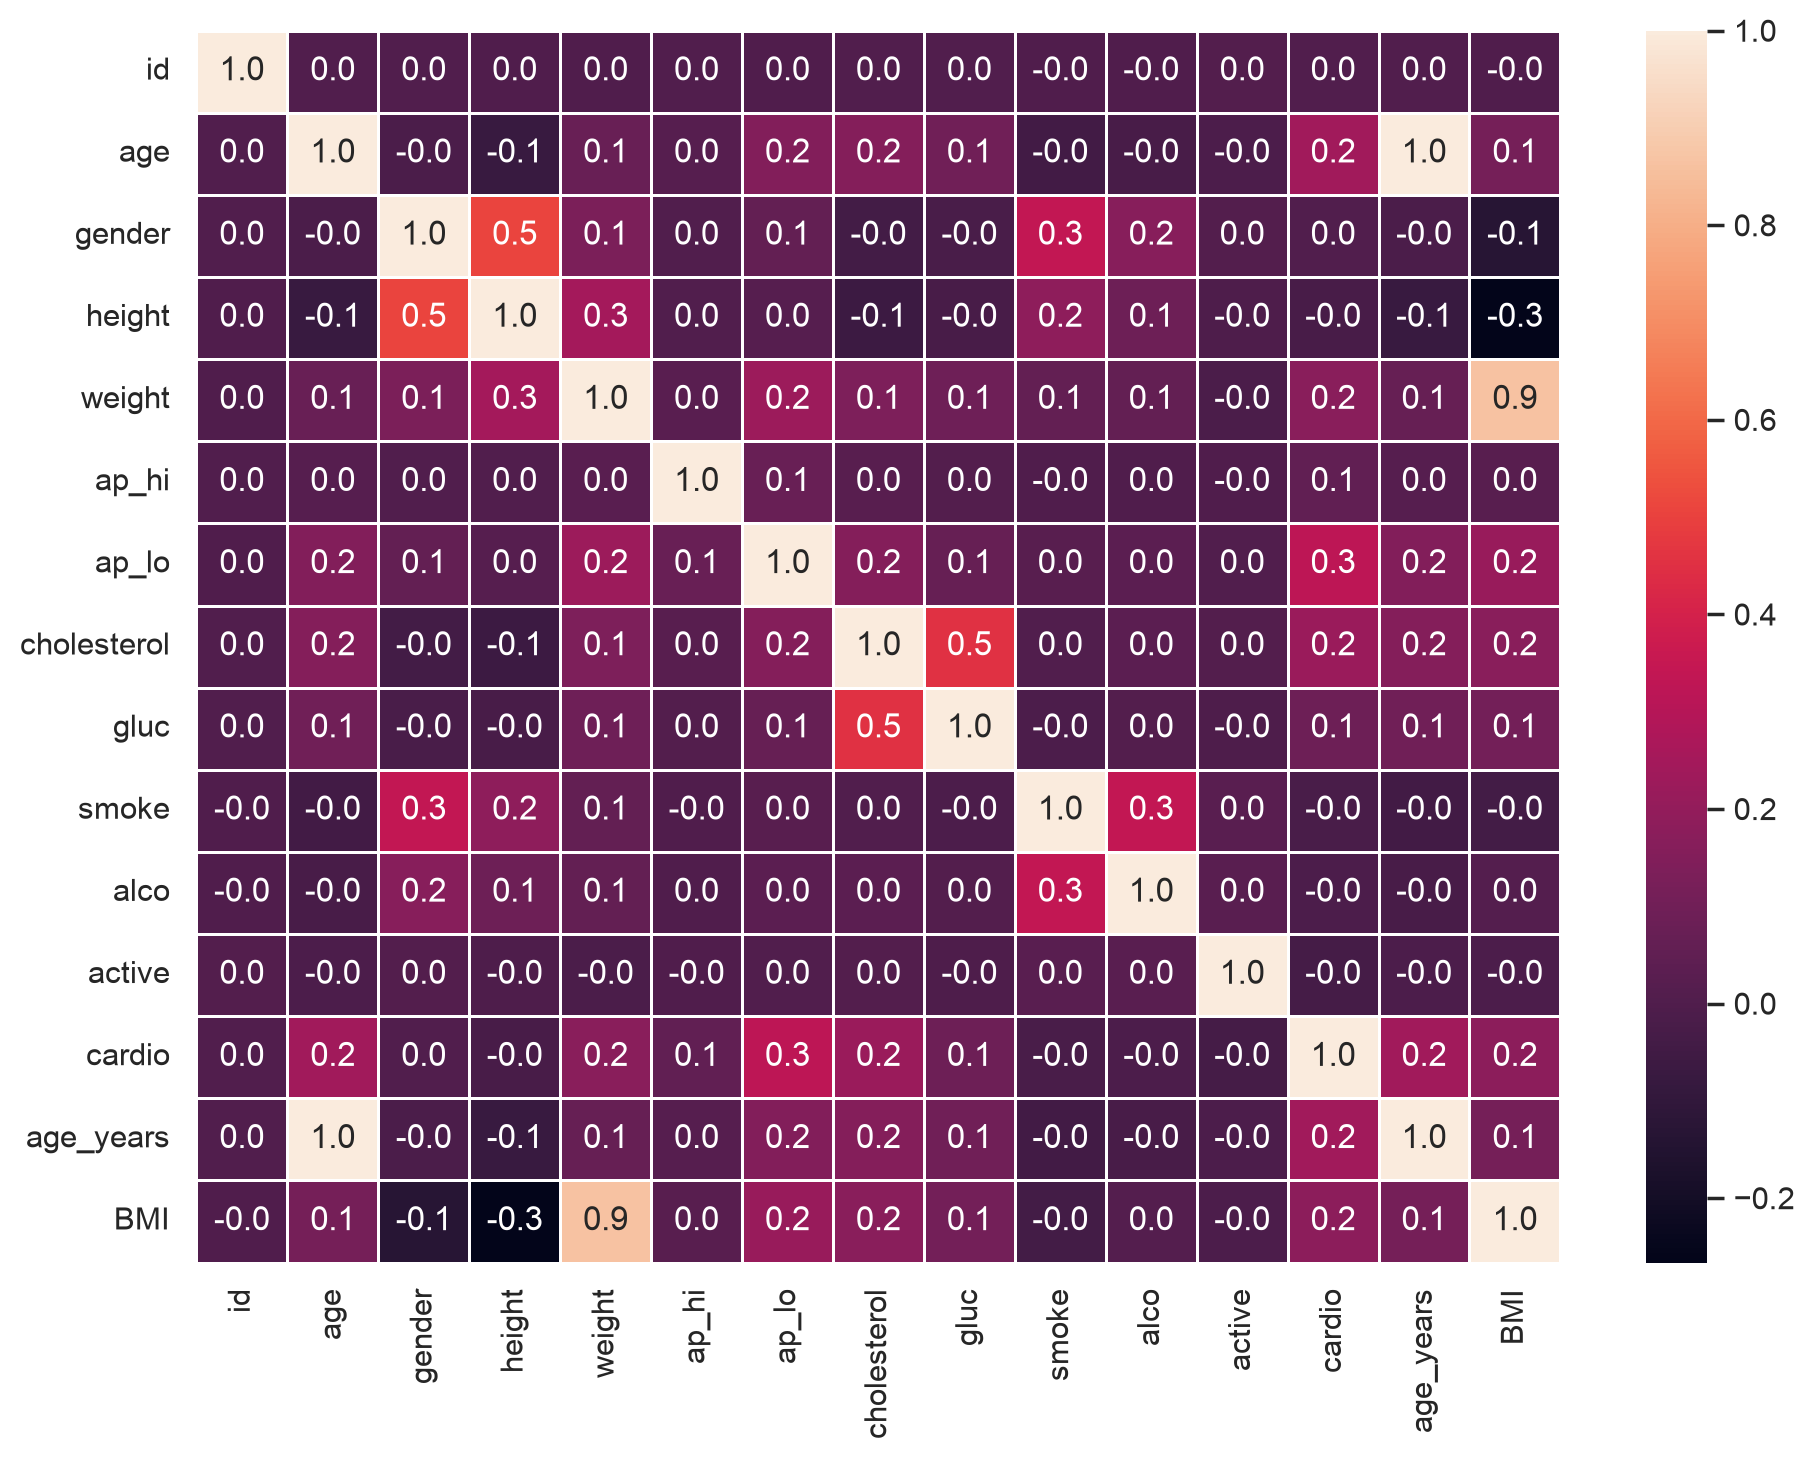

In [59]:
sns.heatmap(df_clean.corr(), annot=True, fmt='.1f', linewidths=0.5)
plt.show()

Pearson correlation measures how strongly two numeric columns move together in a linear way. When one goes up the other goes up as well, and one goes down the other goes down as well.

### 2.2 Height distribution of men and women

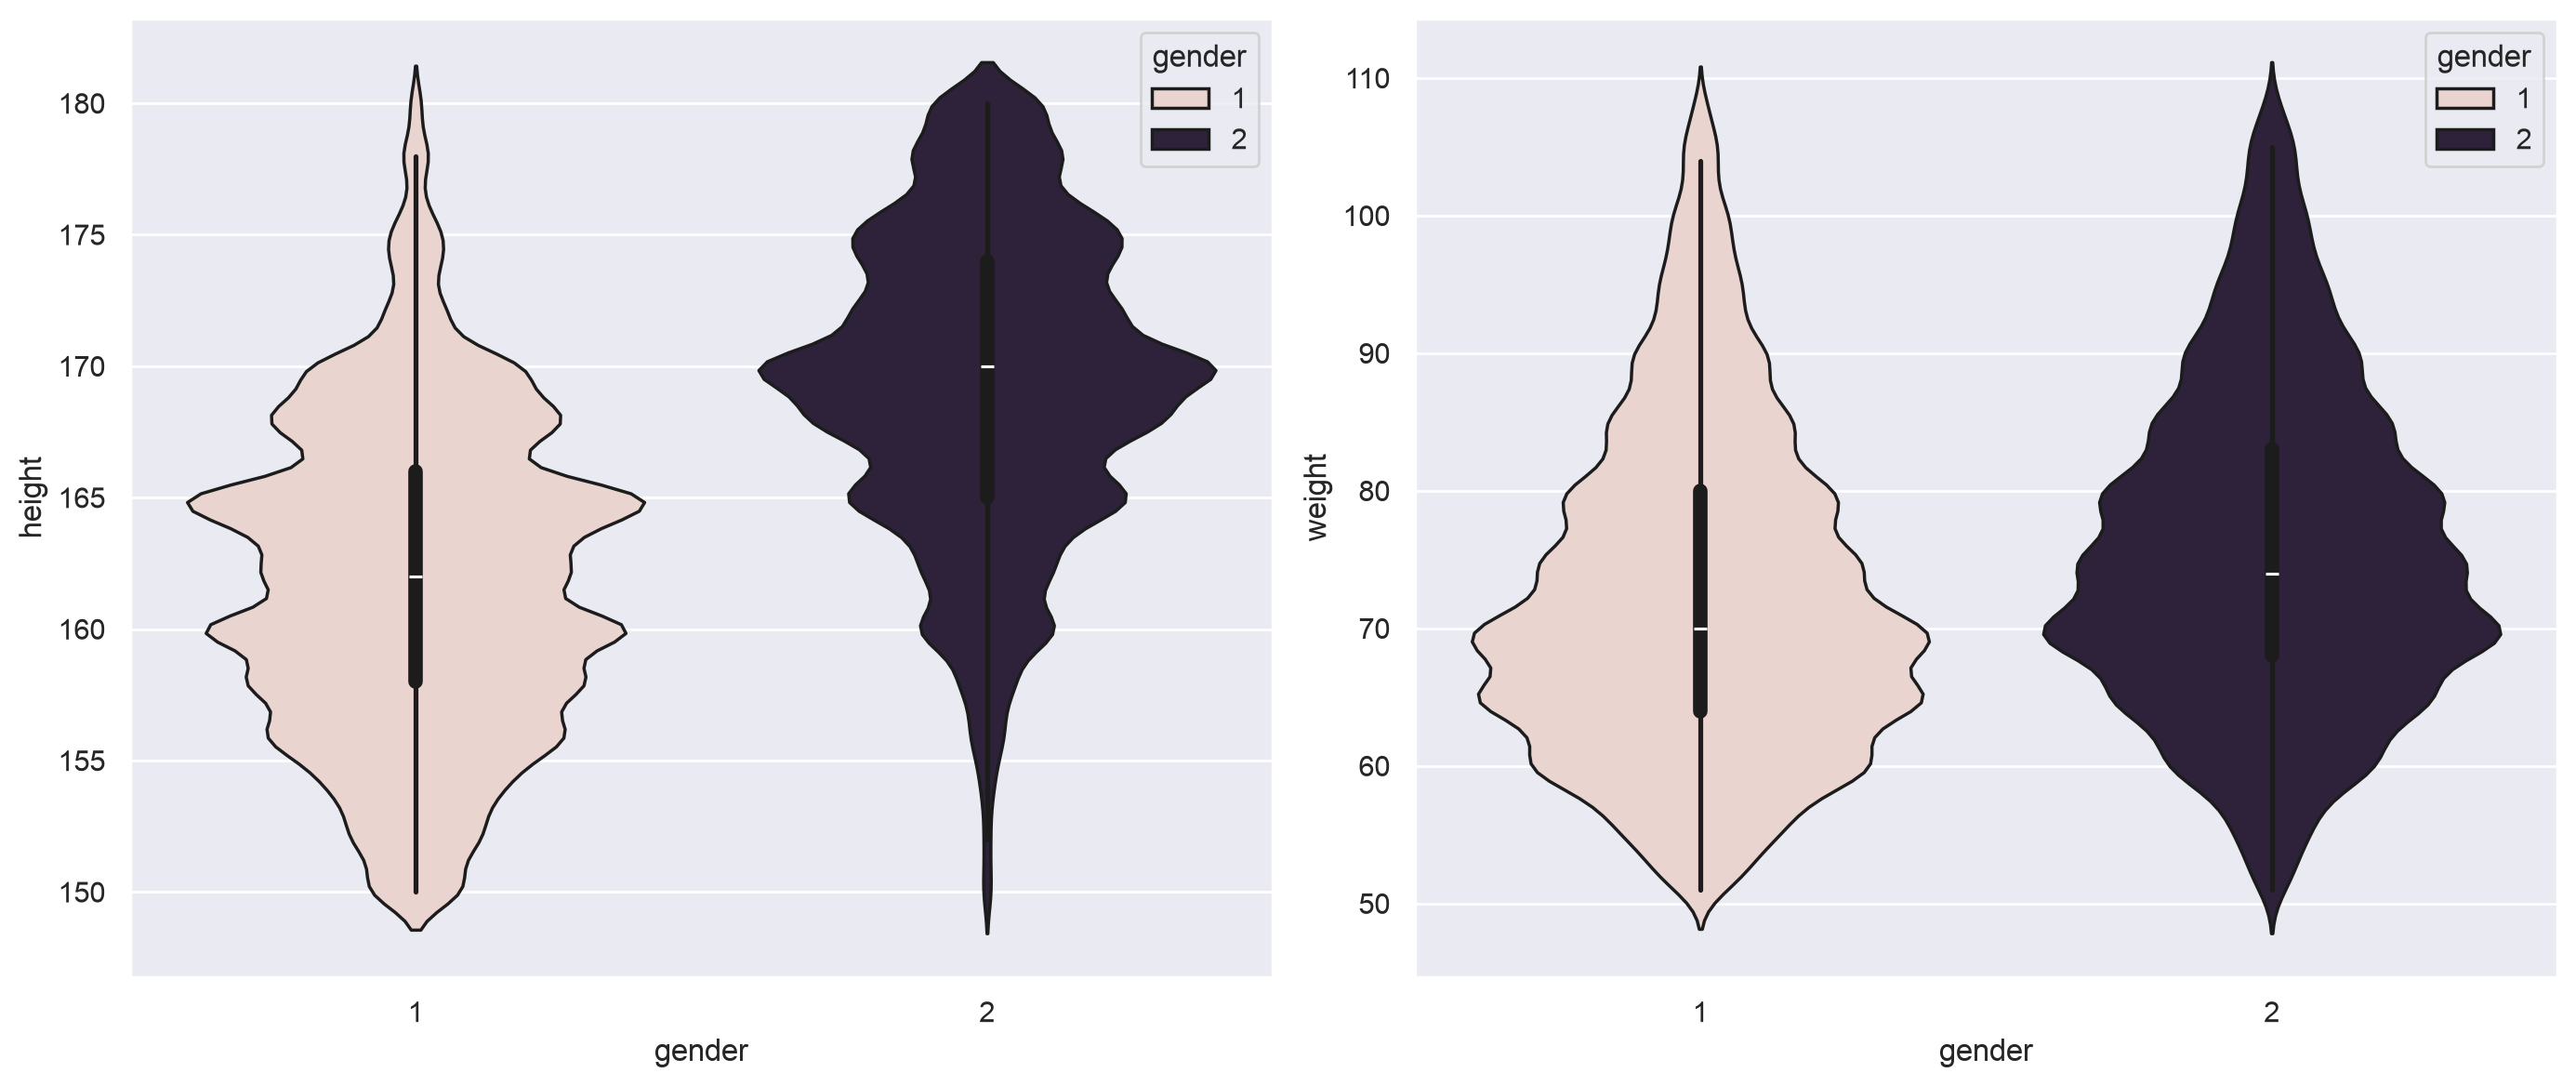

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_melted = pd.melt(
    df_clean,
    value_vars=['height', 'weight'],
    id_vars=['gender']
)

sns.violinplot(x='gender', y='height', data=df_clean, hue='gender', scale='count', ax=axes[0])
sns.violinplot(x='gender', y='weight', data=df_clean, hue='gender', scale='count', ax=axes[1])

plt.tight_layout()
plt.show()

### 2.3 Rank correlation

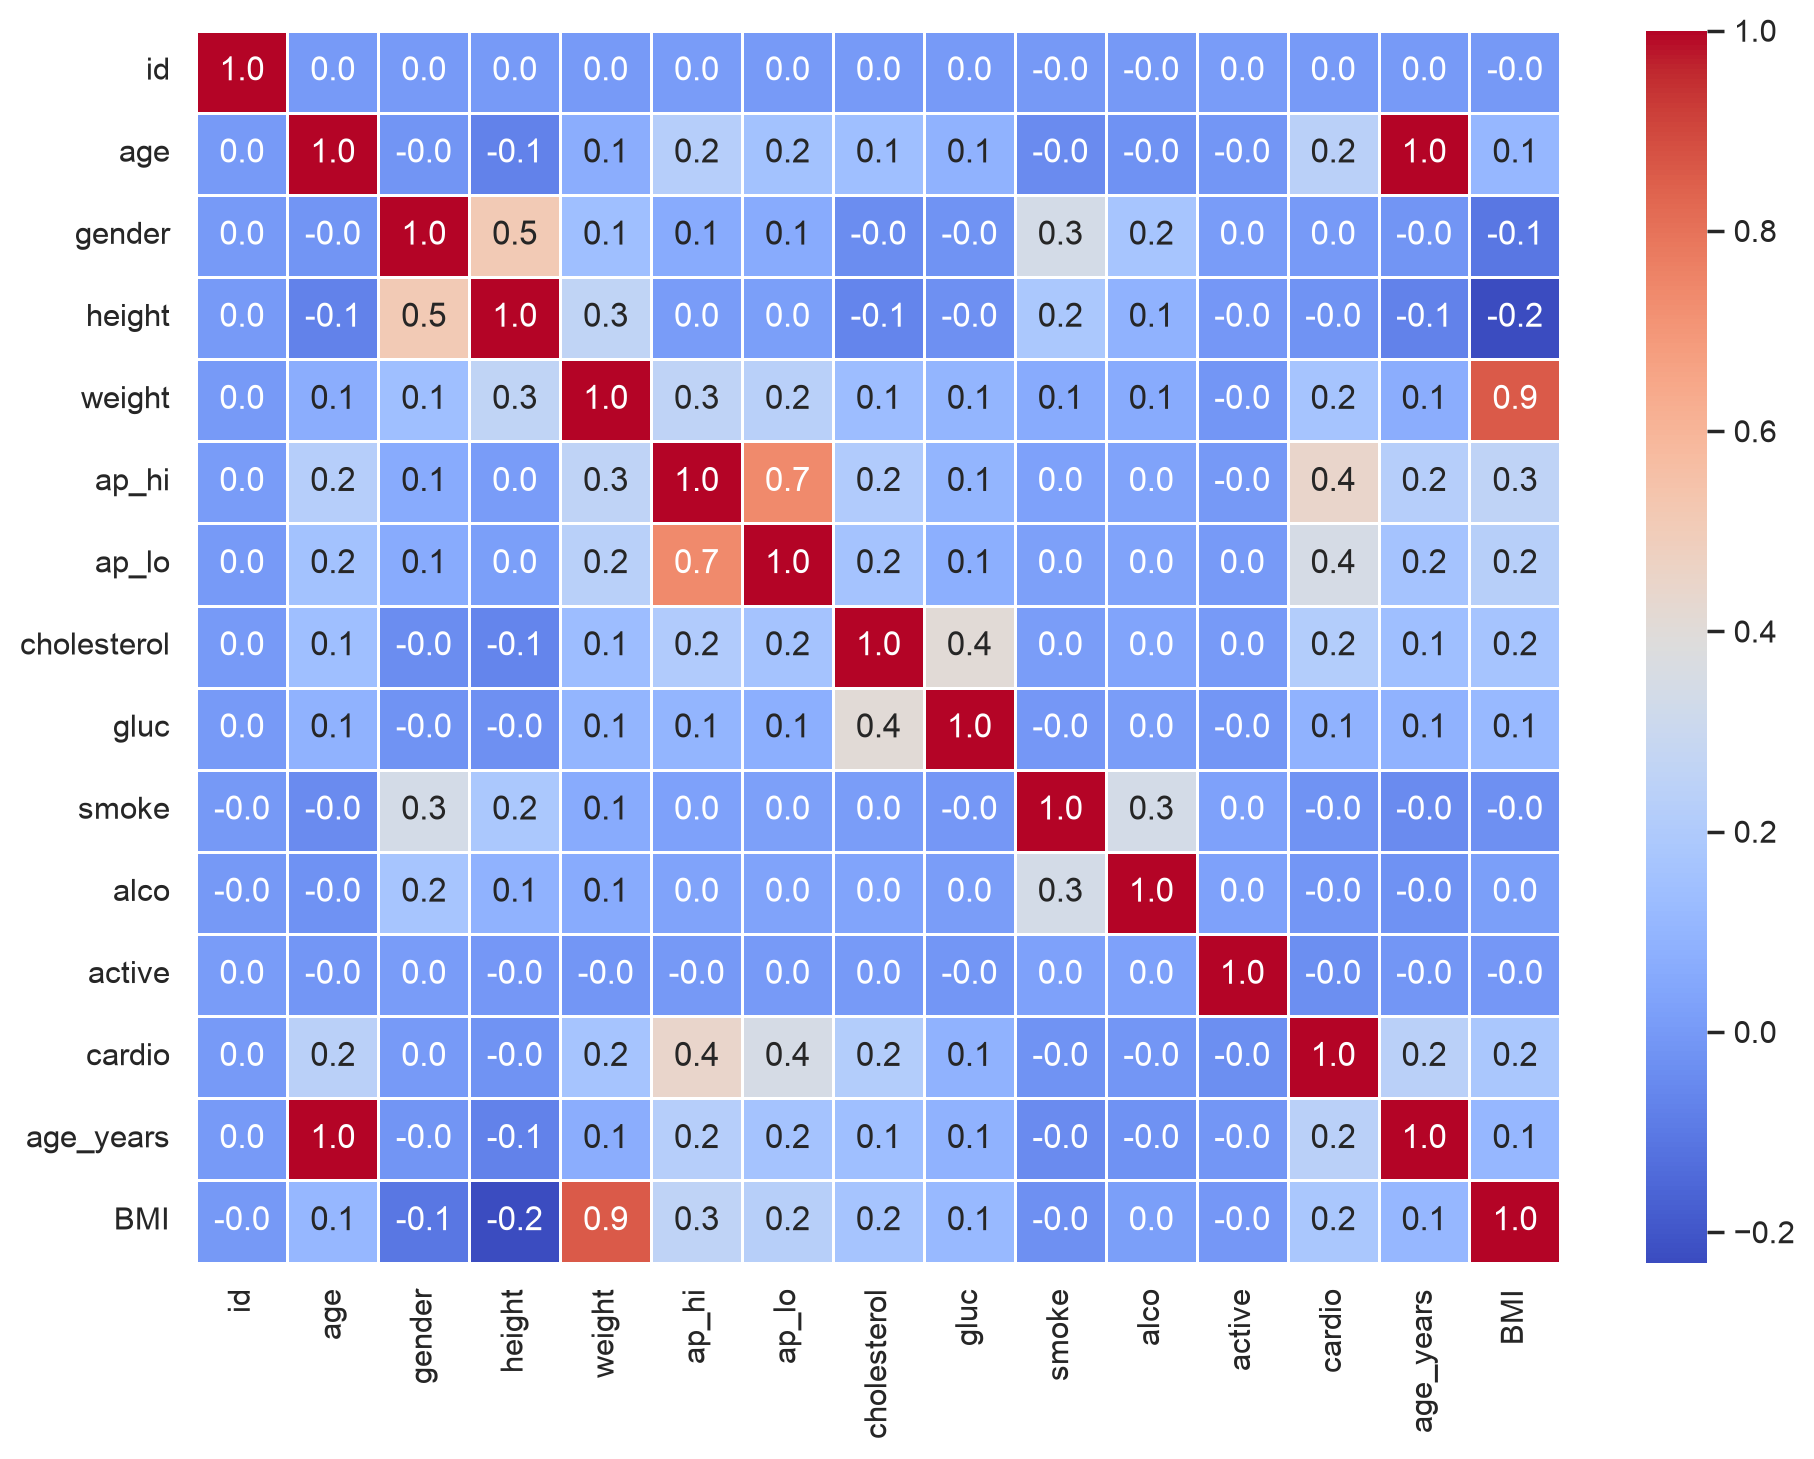

In [69]:
sns.heatmap(
    data=df_clean.corr(method='spearman'),
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap='coolwarm'
)

plt.show()

Pearson correlation measures a linear relatiionship between two numeric variables.
Spearman correlation measures a rank/monotic relationship between two variables.

### 2.4 Age

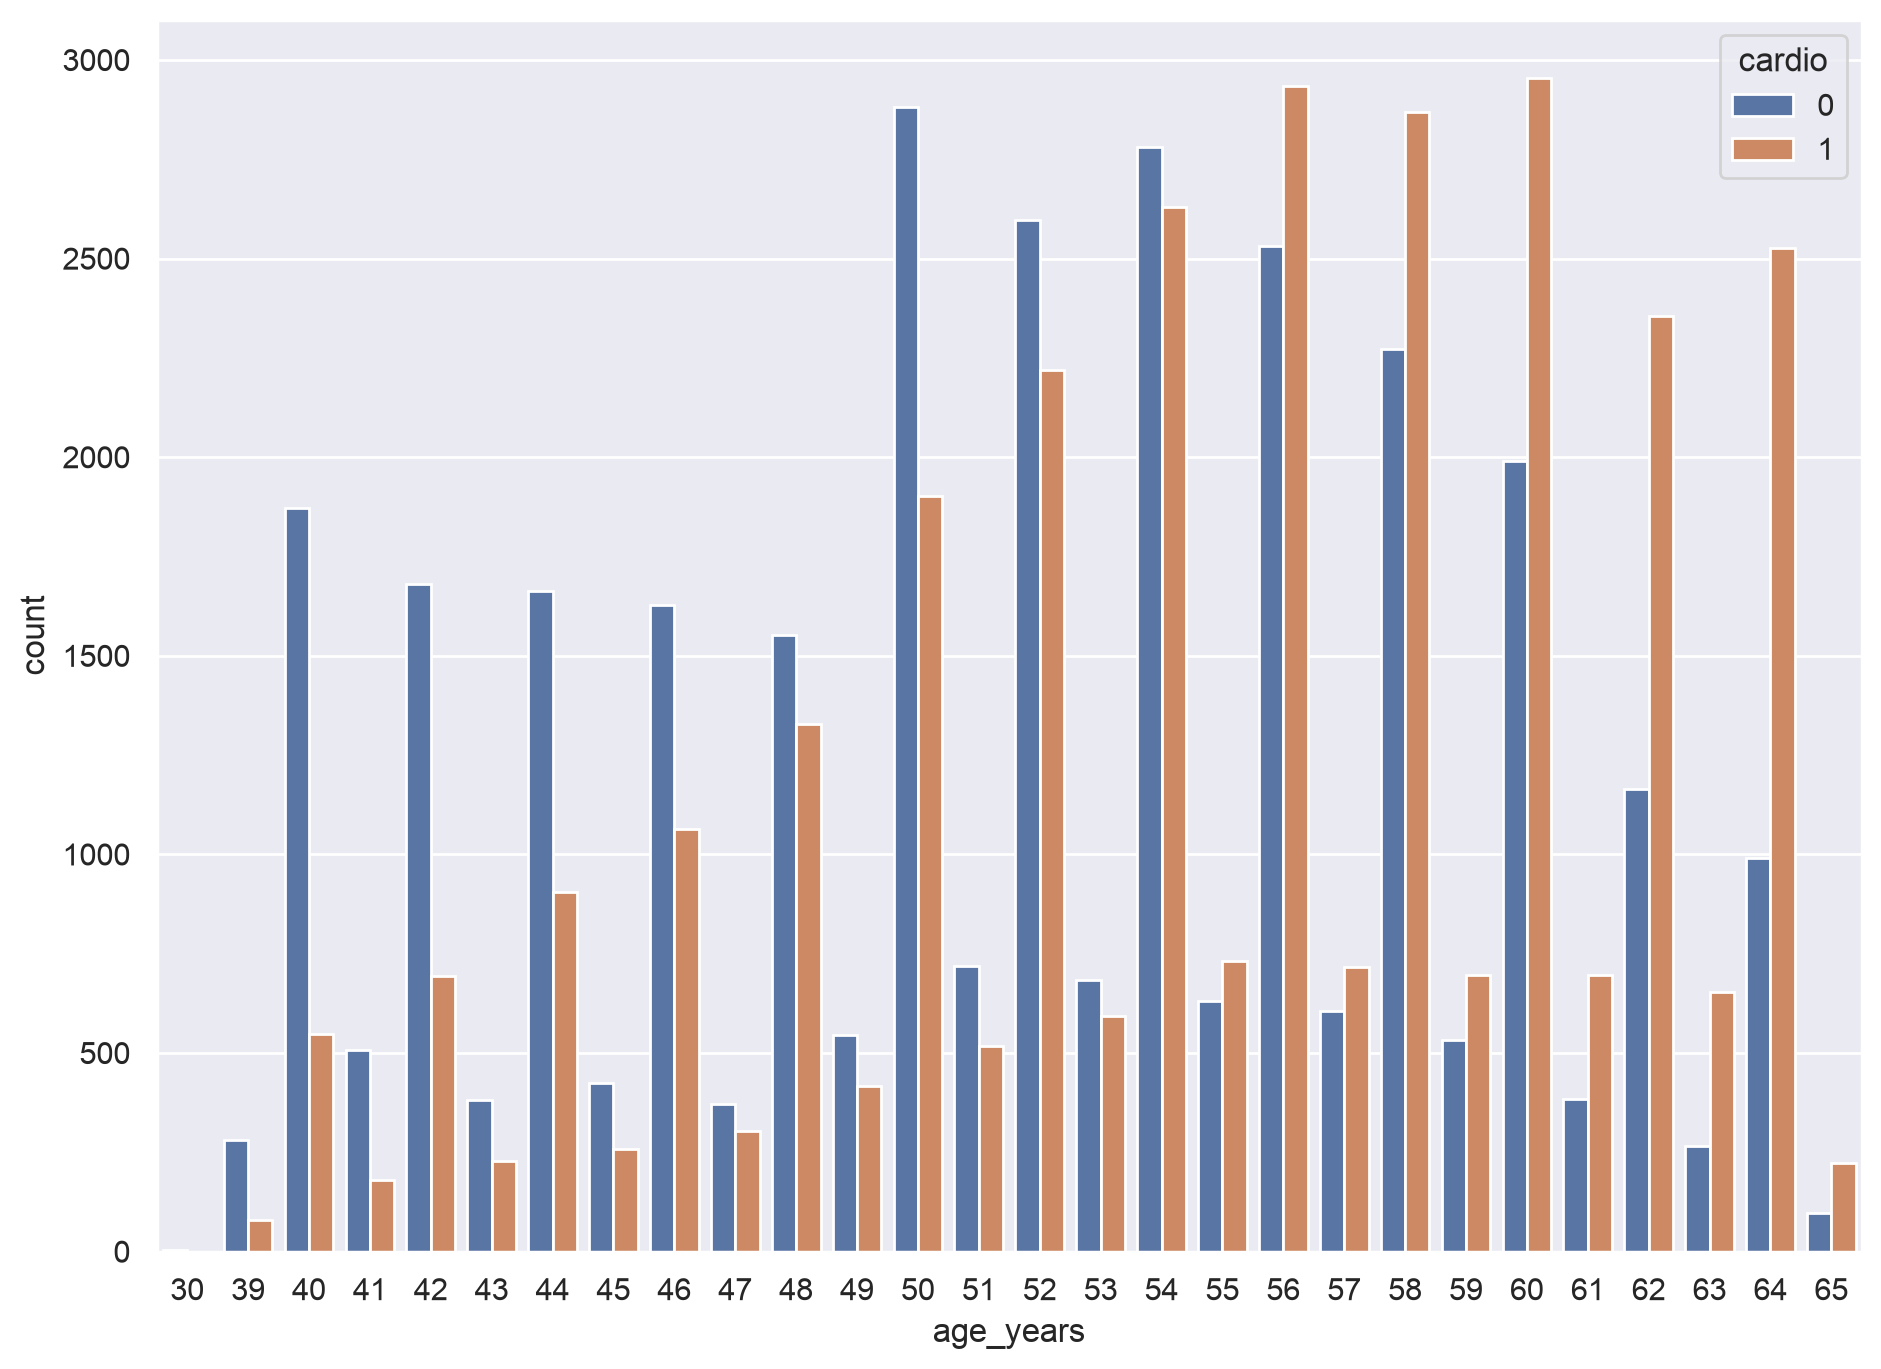

In [73]:
sns.countplot(
    x='age_years',
    hue='cardio',
    data=df_clean
)

plt.show()